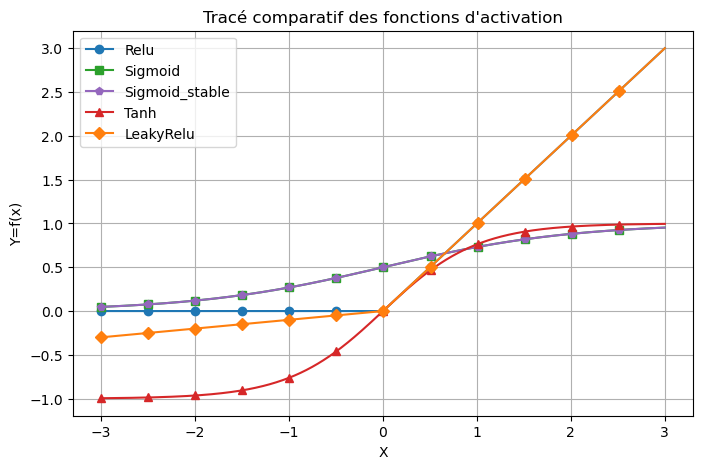

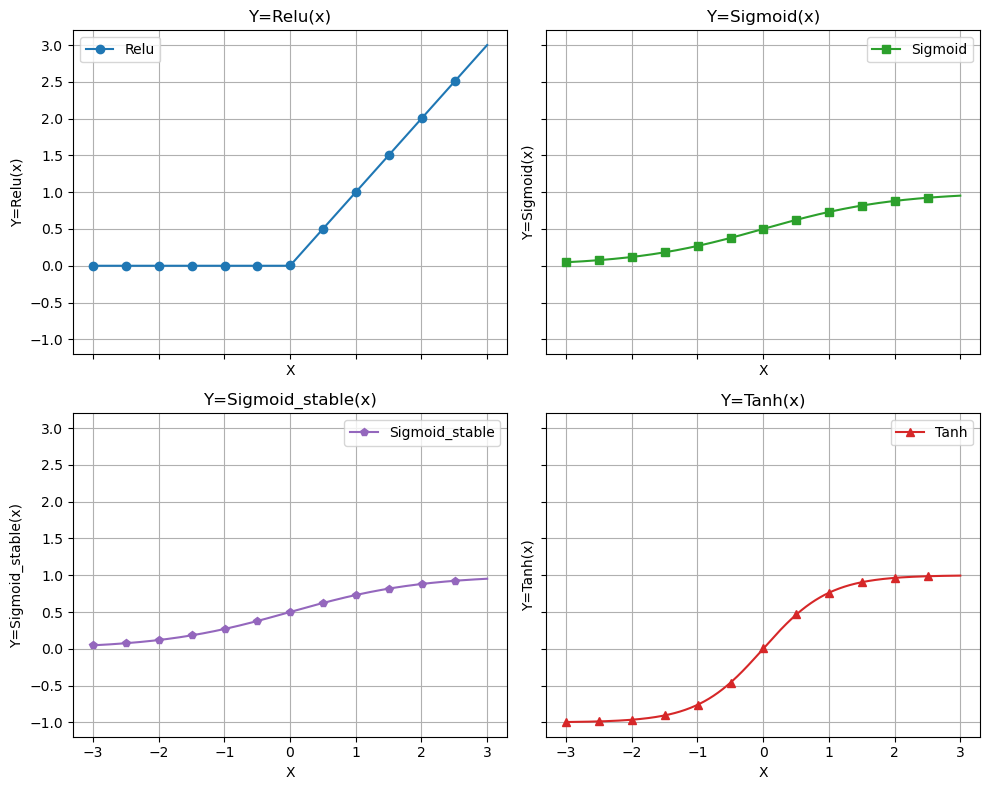

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 600)

activations = {
    "Relu": lambda x: np.maximum(0, x),
    "Sigmoid": lambda x: 1 / (1 + np.exp(-x)),
    "Sigmoid_stable": lambda x: np.where(x > 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x))),
    "Tanh": lambda x: np.tanh(x),
    "LeakyRelu": lambda x, a=0.1: np.where(x > 0, x, a * x),
    "Sofplus": lambda x: np.log(1 + np.exp(x)),
    "ELU": lambda x, alpha=1: np.where(x > 0, x, alpha * (np.exp(x) - 1))
}

d_activations = {
    "Relu": ("z", lambda z: np.where(z > 0, 1, 0)),
    "Sigmoid": ("out", lambda out: out * (1 - out)),
    "Sigmoid_stable": ("out", lambda out: out * (1 - out)),
    "Tanh": ("out", lambda out: 1 - out**2),
    "LeakyRelu": ("z", lambda z, a=0.1: np.where(z > 0, 1, a))
}
couleurs = {
    "Relu": "tab:blue",
    "Sigmoid": "tab:green",
    "Sigmoid_stable": "tab:purple",
    "Tanh": "tab:red",
    "LeakyRelu": "tab:orange",
    "Sofplus": "tab:cyan",
    "ELU": "tab:pink"
}

markers = {
    "Relu": "o",
    "Sigmoid": "s",
    "Sigmoid_stable": "p",
    "Tanh": "^",
    "LeakyRelu": "D",
    "Sofplus": "+",
    "ELU": "*"
}
plt.figure(figsize=(8, 5))
four_functions = ["Relu", "Sigmoid", "Sigmoid_stable", "Tanh", "LeakyRelu"]

for name in ["Relu", "Sigmoid", "Sigmoid_stable", "Tanh", "LeakyRelu"]:
    plt.plot(x, activations[name](x), label=name, color=couleurs[name], 
             marker=markers[name], markevery=50, markersize=6)

plt.title("Tracé comparatif des fonctions d'activation")
plt.xlabel("X")
plt.ylabel("Y=f(x)")
plt.grid(True)
plt.legend()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes_flat = axes.ravel()
four_basic = ["Relu", "Sigmoid", "Sigmoid_stable", "Tanh"]

for i, name in enumerate(four_basic):
    axes_flat[i].plot(x, activations[name](x), label=name, color=couleurs[name], 
                      marker=markers[name], markevery=50)
    axes_flat[i].set_title(f"Y={name}(x)")
    axes_flat[i].set_xlabel("X")
    axes_flat[i].set_ylabel(f"Y={name}(x)")
    axes_flat[i].grid(True)
    axes_flat[i].legend()

plt.tight_layout()
plt.show()

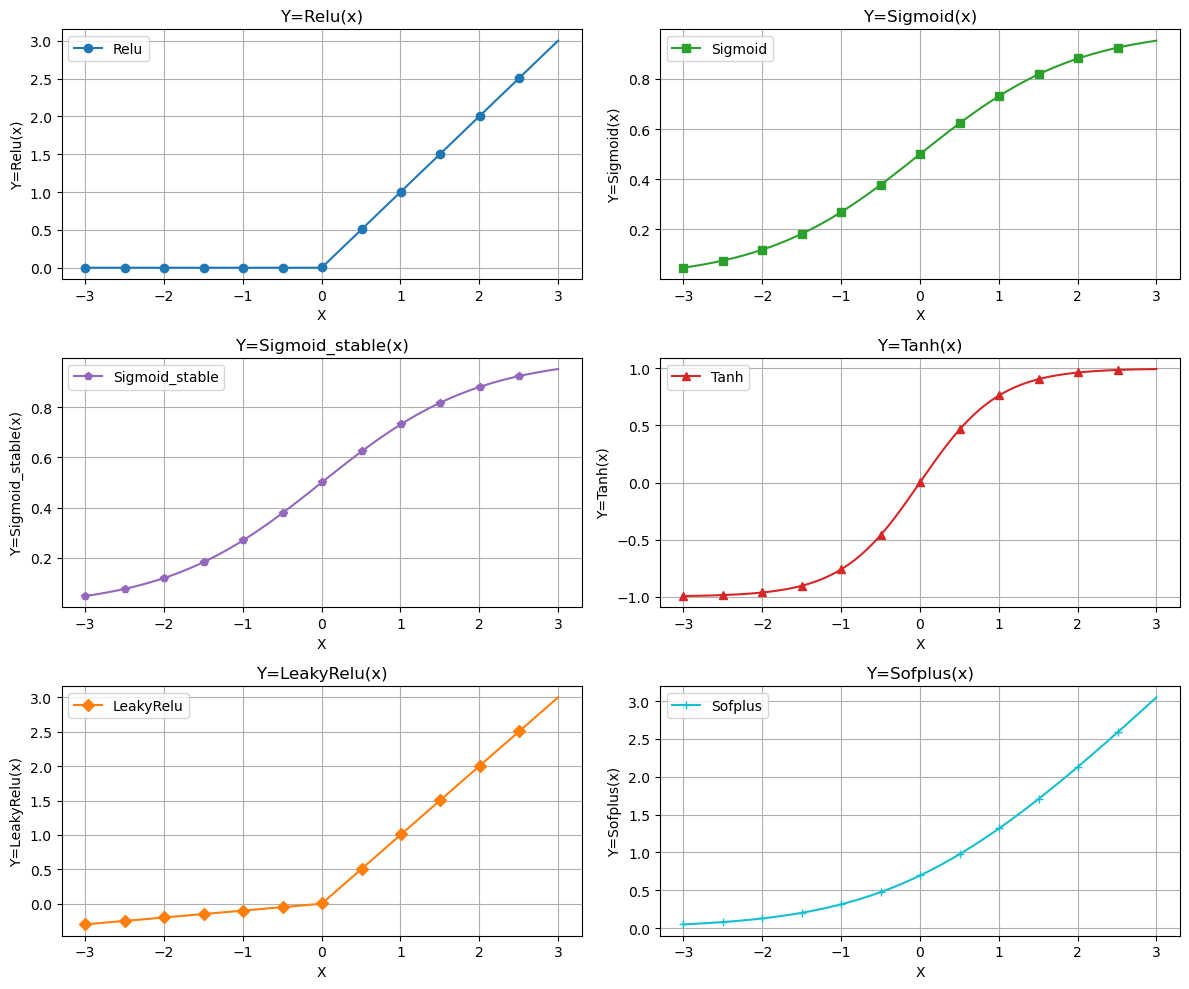

In [3]:
def sub_tracer(rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(12, 10))
    axes_flat = axes.ravel()
    list_acts = ["Relu", "Sigmoid", "Sigmoid_stable", "Tanh", "LeakyRelu", "Sofplus"]
    
    for i, name in enumerate(list_acts):
        axes_flat[i].plot(x, activations[name](x), label=name, color=couleurs[name], 
                          marker=markers[name], markevery=50)
        axes_flat[i].set_title(f"Y={name}(x)")
        axes_flat[i].set_xlabel("X")
        axes_flat[i].set_ylabel(f"Y={name}(x)")
        axes_flat[i].grid(True)
        axes_flat[i].legend()
        
    plt.tight_layout()
    plt.show()

sub_tracer(3, 2)

In [4]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

W1 = np.array([[ 0.06286511, -0.06605243,  0.32021133],
               [ 0.05245006, -0.26783469,  0.18079753]])
b1 = np.array([[0., 0., 0.]])
W2 = np.array([[ 0.65200002], [ 0.47354048], [-0.35186762]])
b2 = np.array([[0.]])

act_hid = activations["Tanh"]
act_out = activations["Sigmoid_stable"]

In [5]:
def forward(X, W1, b1, W2, b2, act_hid, act_out):
    Z1 = np.dot(X, W1) + b1
    A1 = act_hid(Z1)
    Z2 = np.dot(A1, W2) + b2
    y_hat = act_out(Z2)
    cache = (X, Z1, A1, Z2, y_hat)
    return y_hat, cache

def mse(y_hat, y):
    return np.mean((y_hat - y) ** 2)

In [6]:
def train(X, y, W1, b1, W2, b2, lr=0.8, epochs=4000, f_act_hid=act_hid, f_act_out=act_out):
    losses = []
    for epoch in range(epochs):
        y_hat, cache = forward(X, W1, b1, W2, b2, f_act_hid, f_act_out)
        X_c, Z1, A1, Z2, y_hat_c = cache
        
        L = mse(y_hat, y)
        losses.append(L)
        
        N = y.shape[0]
        
        dy = 2 * (y_hat - y) / N
        dZ2 = dy * (y_hat * (1 - y_hat))
        dw2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        
        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (1 - A1**2)
        dW1 = np.dot(X_c.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        
        W2 -= lr * dw2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
        
        if epoch % 400 == 0:
            print(f"epoch={epoch:4d} loss={L:.6f}")
            
    return W1, b1, W2, b2, losses

W1t, bit, W2t, b2t, losses = train(X, y, W1.copy(), b1.copy(), W2.copy(), b2.copy(), lr=0.8, epochs=4000)

epoch=   0 loss=0.252173
epoch= 400 loss=0.009484
epoch= 800 loss=0.002013
epoch=1200 loss=0.001073
epoch=1600 loss=0.000723
epoch=2000 loss=0.000543
epoch=2400 loss=0.000433
epoch=2800 loss=0.000360
epoch=3200 loss=0.000308
epoch=3600 loss=0.000268


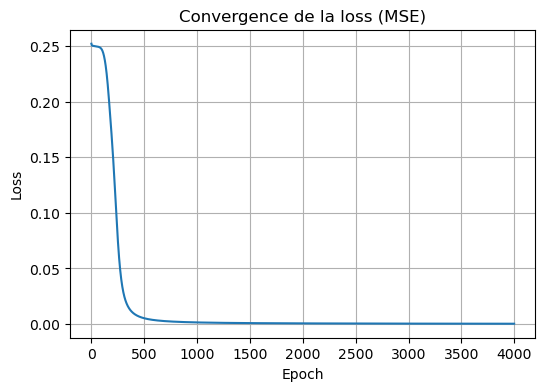

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Convergence de la loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [8]:
def make_noisy_xor(n=100, noise=0.05, flip=0.04, seed=0):
    rng = np.random.default_rng(seed)
    coins = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    labels = np.array([[0], [1], [1], [0]])
    
    X = np.repeat(coins, n, axis=0)
    y = np.repeat(labels, n, axis=0)
    
    X = X + rng.normal(0, noise, X.shape)
    
    mask = rng.random(len(y)) < flip
    y[mask] = 1 - y[mask]
    return X, y

X_noisy, y_noisy = make_noisy_xor(n=100, noise=0.05, flip=0.04)

def split_dataset(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    N = len(X)
    indices = np.arange(N)
    rng.shuffle(indices)
    cut = int((1 - test_ratio) * N)
    
    X_train, X_test = X[indices[:cut]], X[indices[cut:]]
    y_train, y_test = y[indices[:cut]], y[indices[cut:]]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_dataset(X_noisy, y_noisy)

epoch=   0 loss=0.249889
epoch= 400 loss=0.247368
epoch= 800 loss=0.113419
epoch=1200 loss=0.043503
epoch=1600 loss=0.039872
epoch=2000 loss=0.039087
epoch=2400 loss=0.038800
epoch=2800 loss=0.038666
epoch=3200 loss=0.038593
epoch=3600 loss=0.038549
epoch=4000 loss=0.038520
epoch=4400 loss=0.038500
epoch=4800 loss=0.038486
epoch=5200 loss=0.038475
epoch=5600 loss=0.038466
epoch=6000 loss=0.038459
epoch=6400 loss=0.038454
epoch=6800 loss=0.038449
epoch=7200 loss=0.038445
epoch=7600 loss=0.038441
epoch=8000 loss=0.038438
epoch=8400 loss=0.038435
epoch=8800 loss=0.038433
epoch=9200 loss=0.038431
epoch=9600 loss=0.038428
epoch=10000 loss=0.038427
epoch=10400 loss=0.038425
epoch=10800 loss=0.038423
epoch=11200 loss=0.038421
epoch=11600 loss=0.038420
epoch=12000 loss=0.038418
epoch=12400 loss=0.038417
epoch=12800 loss=0.038416
epoch=13200 loss=0.038415
epoch=13600 loss=0.038413
epoch=14000 loss=0.038412
epoch=14400 loss=0.038411
epoch=14800 loss=0.038410
epoch=15200 loss=0.038409
epoch=15600

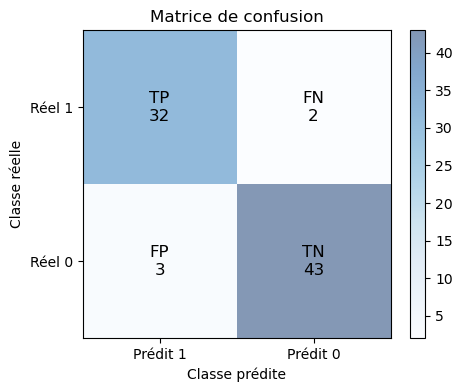

In [9]:
rng = np.random.default_rng(42)
W1_n = rng.normal(0, 0.1, (2, 3))
b1_n = np.zeros((1, 3))
W2_n = rng.normal(0, 0.1, (3, 1))
b2_n = np.zeros((1, 1))

W1_trained, b1_trained, W2_trained, b2_trained, _ = train(
    X_train, y_train, W1_n, b1_n, W2_n, b2_n, lr=0.5, epochs=100000
)

y_score, _ = forward(X_test, W1_trained, b1_trained, W2_trained, b2_trained, act_hid, act_out)
y_pred_test = (y_score >= 0.5).astype(int)

def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix(y_test, y_pred_test)

cm = np.array([[TP, FN], [FP, TN]])
cm_txt = np.array([[f"TP\n{TP}", f"FN\n{FN}"], [f"FP\n{FP}", f"TN\n{TN}"]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", alpha=0.5)
plt.title("Matrice de confusion")
plt.colorbar()
plt.xticks([0, 1], ["Prédit 1", "Prédit 0"])
plt.yticks([0, 1], ["Réel 1", "Réel 0"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_txt[i, j], ha="center", va="center", fontsize=12)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

Accuracy: 0.9375
Precision: 0.9142857142857143
Recall: 0.9411764705882353
F1: 0.9275362318840579


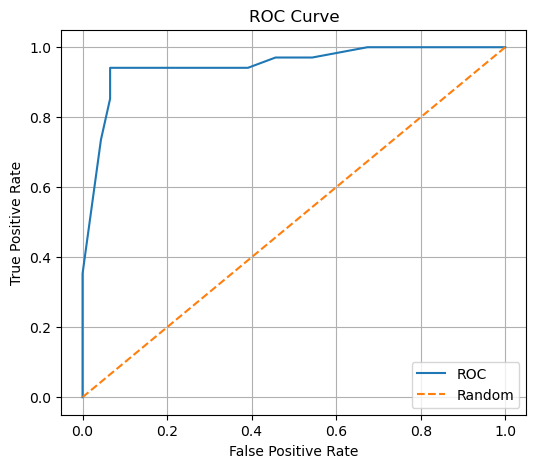

AUC = 0.9491687979539641


In [10]:
def classification_metrics(TP, TN, FP, FN):
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1

acc, prec, rec, f1 = classification_metrics(TP, TN, FP, FN)
print(f"Accuracy: {acc}\nPrecision: {prec}\nRecall: {rec}\nF1: {f1}")

def roc_curve(y_true, y_score):
    thresholds = np.linspace(1, 0, 200)
    TPR = []
    FPR = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tp, tn, fp, fn = confusion_matrix(y_true, y_pred)
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        TPR.append(tpr)
        FPR.append(fpr)
    return np.array(FPR), np.array(TPR)

FPR, TPR = roc_curve(y_test, y_score)

plt.figure(figsize=(6, 5))
plt.plot(FPR, TPR, label="ROC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()

import scipy.integrate as integr
auc = integr.trapezoid(TPR, FPR)
print("AUC =", abs(auc))